In [1]:
import pandas as pd

df = pd.read_csv("../data/HAM10000_metadata.csv")
print(df.shape)
df.head()

(10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [3]:
print(df['dx'].value_counts())
print(df['dx'].value_counts(normalize=True) * 100)

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64
dx
nv       66.949576
mel      11.113330
bkl      10.973540
bcc       5.132302
akiec     3.265102
vasc      1.417873
df        1.148278
Name: proportion, dtype: float64


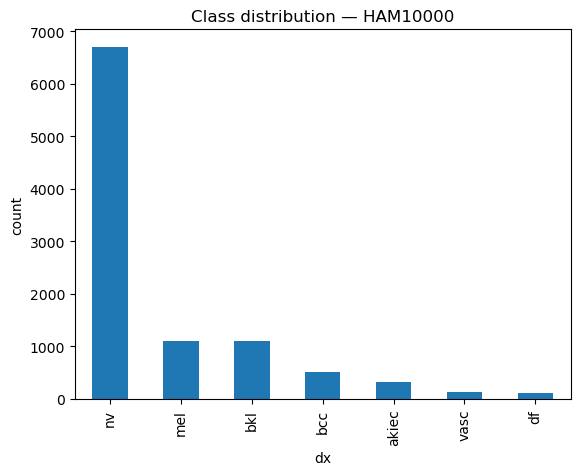

In [4]:
import matplotlib.pyplot as plt

df['dx'].value_counts().plot(kind='bar')
plt.title("Class distribution — HAM10000")
plt.ylabel("count")
plt.show()




In [5]:
import os

image_dir_1 = "../data/HAM10000_images_part_1"
image_dir_2 = "../data/HAM10000_images_part_2"

image_paths = {}
for d in [image_dir_1, image_dir_2]:
    for fname in os.listdir(d):
        image_id = fname.replace(".jpg", "")
        image_paths[image_id] = os.path.join(d, fname)

df['path'] = df['image_id'].map(image_paths)
print(df['path'].isna().sum(), "missing paths")  # should be 0

0 missing paths


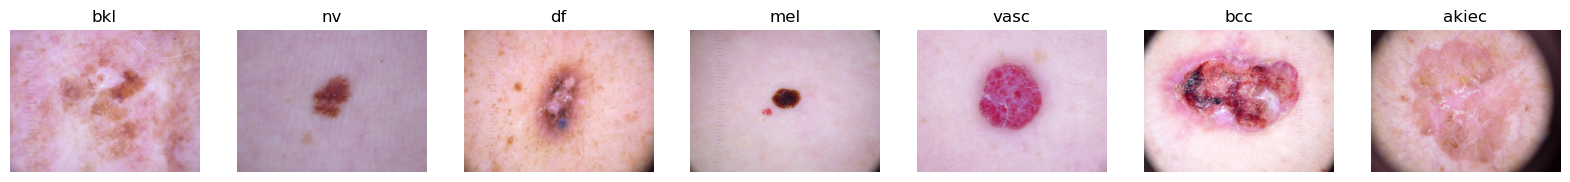

In [6]:
from PIL import Image

classes = df['dx'].unique()
fig, axes = plt.subplots(1, len(classes), figsize=(20, 4))

for ax, cls in zip(axes, classes):
    sample_path = df[df['dx'] == cls]['path'].iloc[0]
    img = Image.open(sample_path)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')

plt.show()